In [1]:
import numpy as np
import rebound
import matplotlib.pyplot as plt
import os
import pandas as pd
from datetime import datetime

os.chdir('../src/')

from prop_elem import *
from sbdynt import *
import h5py

# Identifying Secular Near-Resonant or Resonant Objects
## (Work in Progress)

The indicators and visualizations mentioned in ``proper_elements_advanced.ipynb`` can be useful for identifying objects with unique dynamics occurring within their orbital motion.

For example, identifying obejcts in secular resonance is a very relevant step to understanding the orbital motion of TNOs. We demonstrate here two examples of how the results provided by SBDynT could be used to identify an object that is very near a secular resonance, and what commensurability and occupation of a secular resonance does to the orbital motion of a small body.

We first demonstrate TNO 2019 QQ110, which is discussed in Spencer et al. 2026 as being near the g8+s8 secular resonance with Neptune, causing long-period terms to strongly affect its eccentricity and inclination evolution. 


In [2]:
try:
    f = h5py.File('../example-notebooks/advanced_example_sims/2019QQ110.hdf5','r')

    tno_orb = np.array(f['tno_orb'])
    j_orb = np.array(f['jup_orb'])
    s_orb = np.array(f['sat_orb'])
    u_orb = np.array(f['ura_orb'])
    n_orb = np.array(f['nep_orb'])
    t = np.array(f['time'])

    planet_elems = {'jupiter': j_orb, 'saturn': s_orb, 'uranus': u_orb, 'neptune': n_orb}
finally:
    f.close()

In [3]:
pflag, pe = calc_proper_elements(des='2019 QQ110', times = t, sb_elems = tno_orb, planet_elems = planet_elems, small_planets_flag = False, output_arrays=True)


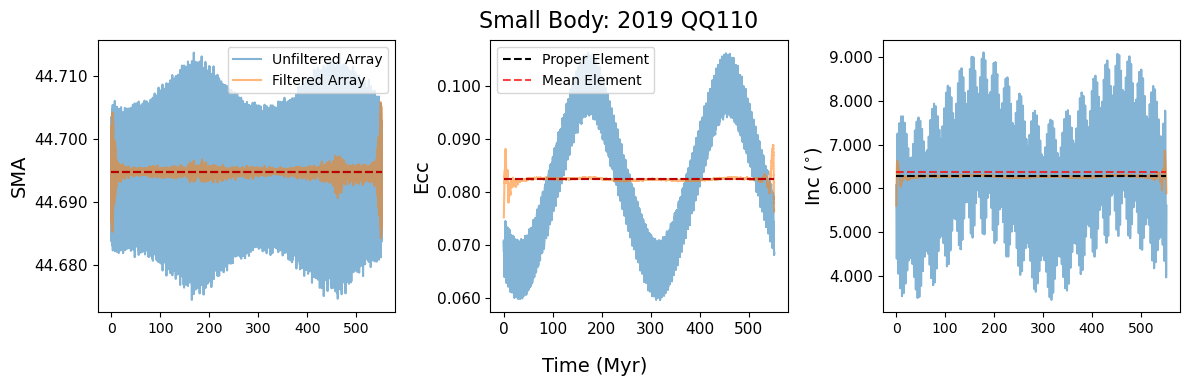

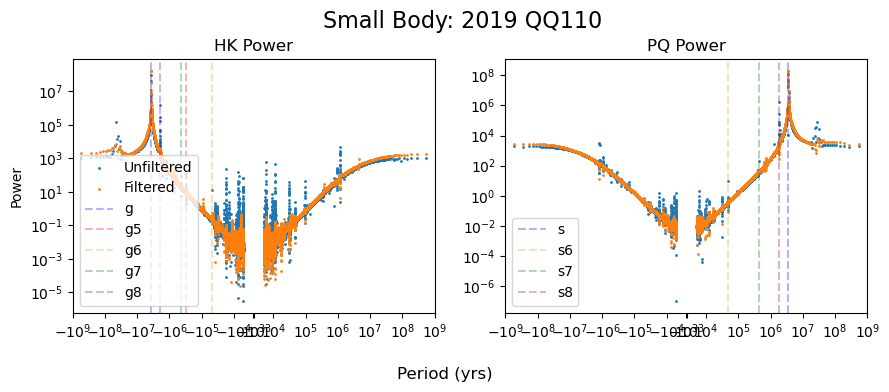

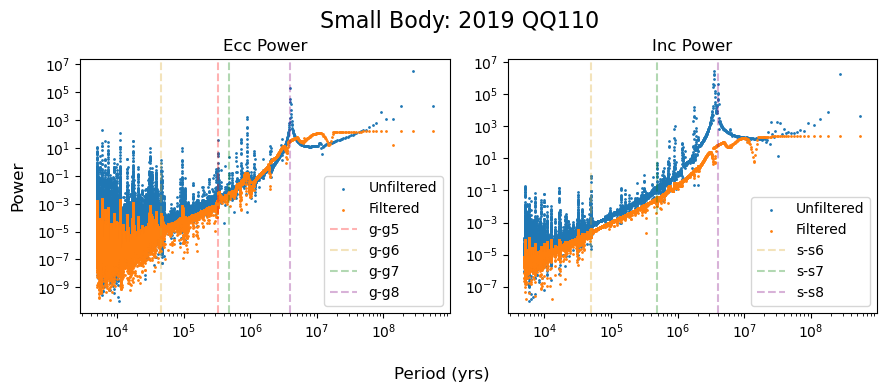

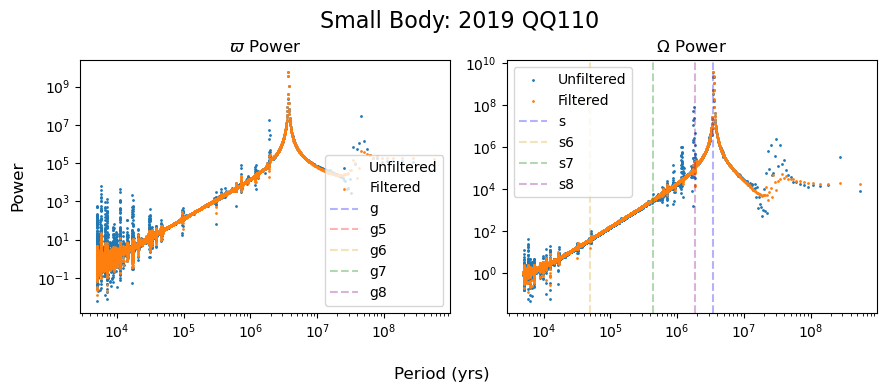

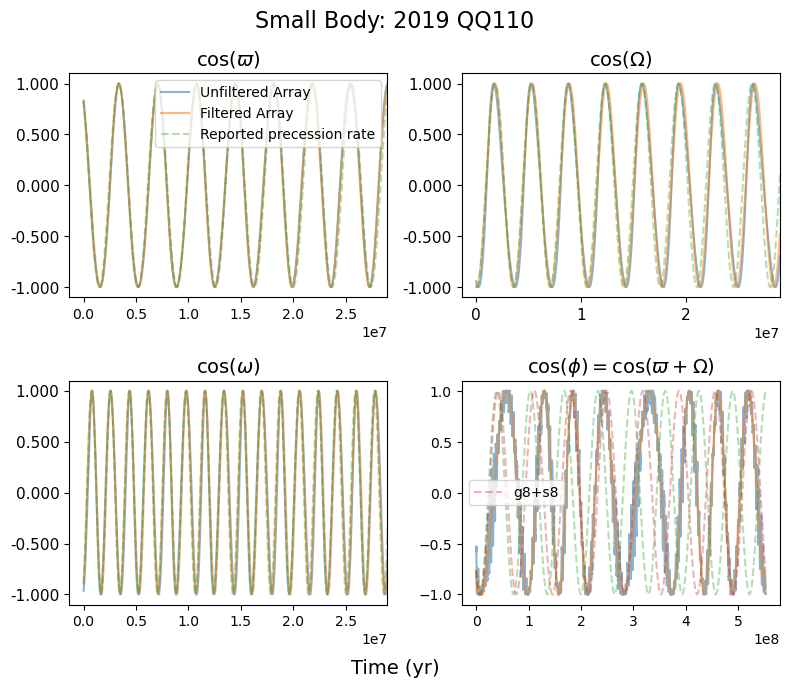

In [4]:
pe.plot_time_arrays()
pe.plot_freq_space('123')
pe.plot_angles(plot_cos=True, ifreqs = {3: (pe.planet_freqs['g8']+pe.planet_freqs['s8'], 'g8+s8')})